In [1]:
%%time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CPU times: total: 609 ms
Wall time: 682 ms


In [2]:

DATA_DIR = Path("./outputs/Machine Learning Models_Horizon12/")  

extreme_sensitivity_files = ["extreme_sensitivity_results_Machine Learning Models_Horizon12_ada.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_avax.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_bch.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_btc.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_doge.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_eth.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_link.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_ltc.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_xrp.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models_Horizon12_All.xlsx",]

validation_cumulative_files = ["test_cumulative_results_Machine Learning Models_Horizon12_ada.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_avax.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_bch.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_btc.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_doge.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_eth.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_link.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_ltc.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_xrp.xlsx",
                               "test_cumulative_results_Machine Learning Models_Horizon12_All.xlsx",]

def read_and_union(filenames):
    dfs = []
    for name in filenames:
        df = pd.read_excel(DATA_DIR / name)
        df["source_file"] = name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

df_extreme_sensitivity = read_and_union(extreme_sensitivity_files)
df_validation_cumulative = read_and_union(validation_cumulative_files)

print(df_extreme_sensitivity.shape)
print(df_validation_cumulative.shape)

(720, 22)
(40, 15)


In [3]:
df_extreme_sensitivity.columns

Index(['Script name', 'Coin', 'Model', 'Extreme percentile',
       'Actual volume threshold', 'Train prevalence', 'Validation prevalence',
       'Test prevalence', 'Number of test extremes',
       'Predicted-volume threshold', 'Validation F1', 'Test PR-AUC',
       'PR-AUC lift over random', 'Test precision', 'Test recall', 'Test F1',
       'True positives', 'False positives', 'False negatives',
       'True negatives', 'source_file', 'Coins with defined PR-AUC'],
      dtype='object')

In [4]:
df_validation_cumulative.columns

Index(['Script name', 'Split', 'Coin', 'Model', 'MAE', 'RMSE', 'R2', 'RMSLE',
       'Mean error', 'Actual mean', 'Prediction mean', 'Actual median',
       'Prediction median', 'Number of observations', 'source_file'],
      dtype='object')

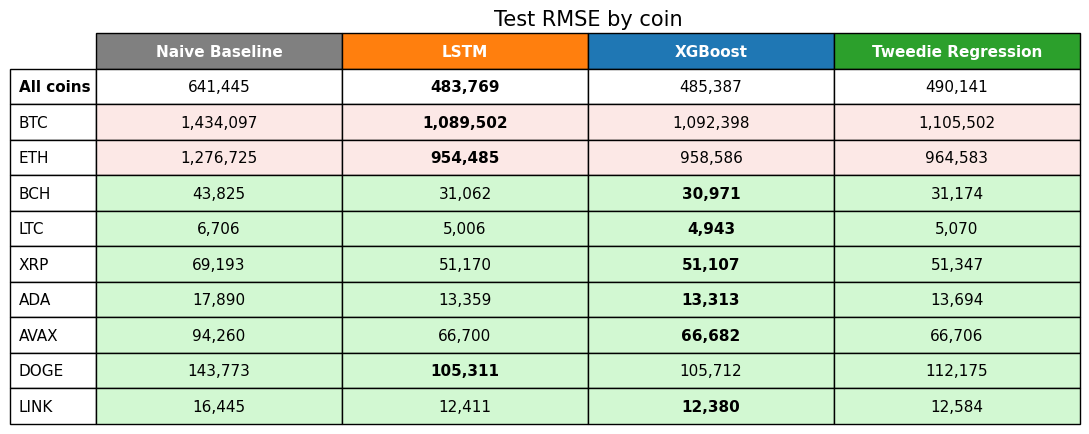

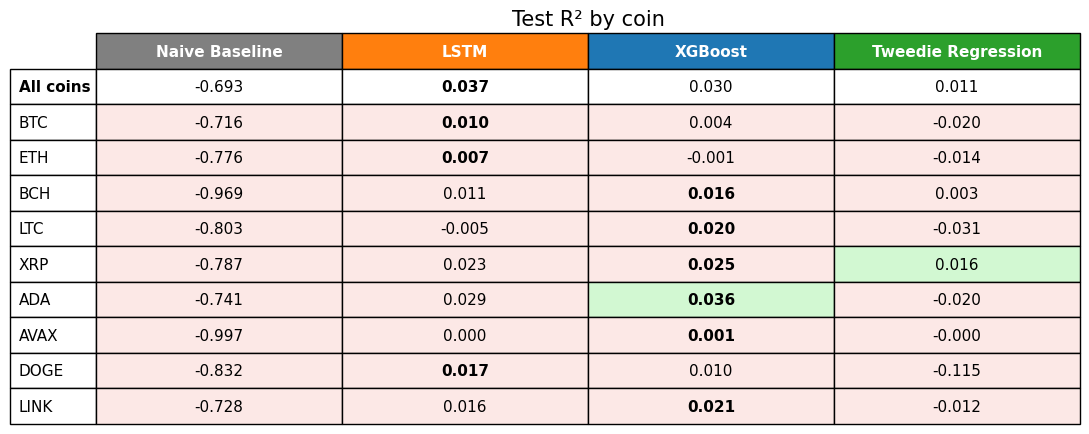

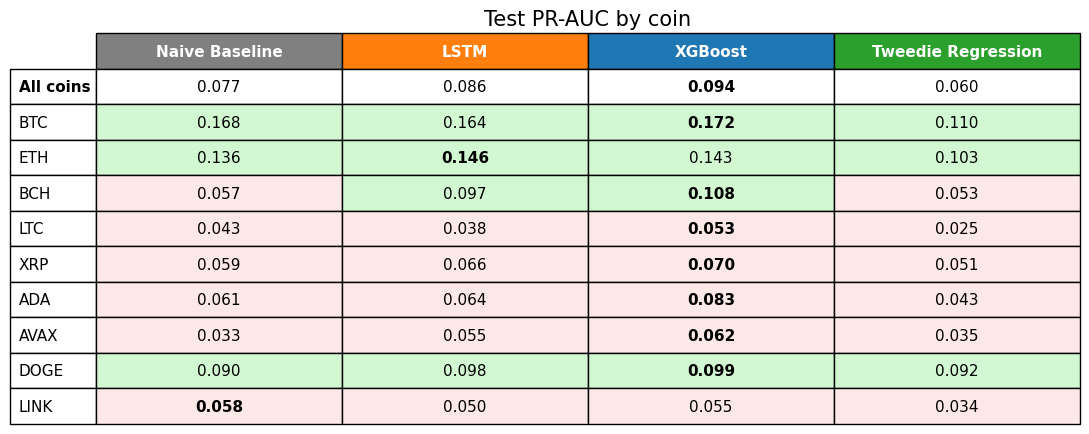

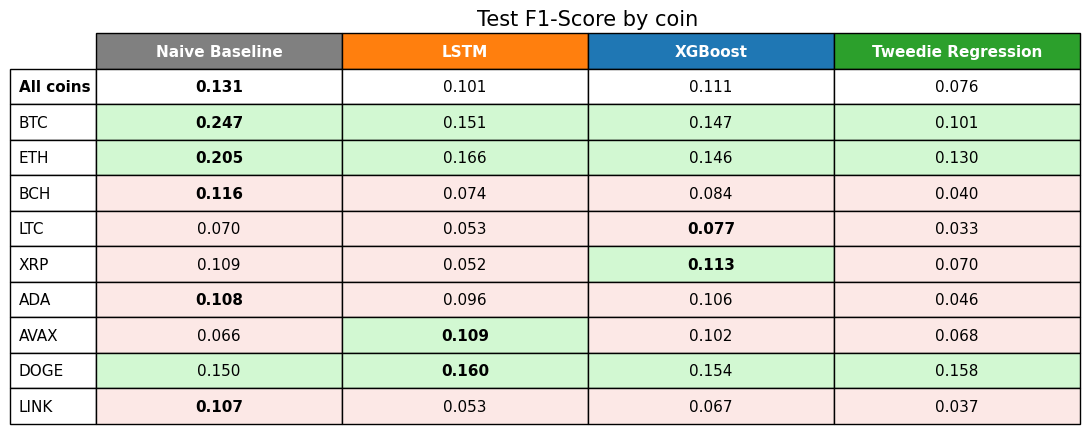

In [25]:

COIN_ORDER = ["All", "btc", "eth", "bch", "ltc", "xrp", "ada", "avax", "doge", "link"]
MODEL_ORDER = ["Naive Baseline","LSTM", "XGBoost", "Tweedie Regression"]

def order_grid(grid):
    coins = [c for c in COIN_ORDER if c in grid.index]
    coins += [c for c in grid.index if c not in COIN_ORDER]
    models = [m for m in MODEL_ORDER if m in grid.columns]
    models += [m for m in grid.columns if m not in MODEL_ORDER]
    return grid.reindex(index=coins, columns=models)

# ------------------------------------------------------------
# RMSE and R2 grids
# ------------------------------------------------------------

cumulative = df_validation_cumulative.copy()

if "Split" in cumulative.columns:
    cumulative = cumulative.loc[cumulative["Split"].eq("Test")]

cumulative = cumulative.loc[~cumulative["Coin"].str.contains("pooled", case=False, na=False)]

duplicates = cumulative.duplicated(subset=["Coin", "Model"]).sum()

rmse_grid = order_grid(cumulative.pivot(index="Coin", columns="Model", values="RMSE"))
r2_grid = order_grid(cumulative.pivot(index="Coin", columns="Model", values="R2"))

# ------------------------------------------------------------
# PR-AUC and F1 grids (averaged across percentiles)
# ------------------------------------------------------------

extreme = df_extreme_sensitivity.copy()

pr_auc_grid = order_grid(extreme.pivot_table(index="Coin", columns="Model",values="Test PR-AUC", aggfunc="mean"))
f1_grid = order_grid(extreme.pivot_table(index="Coin", columns="Model",values="Test F1", aggfunc="mean"))

pr_auc_counts = order_grid(extreme.pivot_table(index="Coin", columns="Model",values="Test PR-AUC", aggfunc="count"))

n_percentiles = extreme["Extreme percentile"].nunique()

# ------------------------------------------------------------
# Presentation
# ------------------------------------------------------------

_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
_chart_order = ['Naive Baseline', 'XGBoost', 'LSTM', 'Tweedie Regression']
MODEL_COLORS = {m: 'grey' for m in _chart_order if 'naive' in m.lower()}
MODEL_COLORS.update({m: _cycle[i % len(_cycle)]
                     for i, m in enumerate([m for m in _chart_order if 'naive' not in m.lower()])})

def grid_table(grid, decimals, best, title):
    """Table figure in the chart style; best model per coin in bold, missing cells as em-dashes."""
    v = grid.rename(index=lambda c: 'All coins' if c == 'All' else str(c).upper())
    text = [['—' if pd.isna(x) else f'{x:,.{decimals}f}' for x in row] for row in v.to_numpy()]

    fig, ax = plt.subplots(figsize=(11, (len(v) + 1) * 0.35 + 0.6))
    ax.axis('off')
    ax.set_title(title, fontsize=15, pad=6)
    table = ax.table(cellText=text, rowLabels=v.index, colLabels=v.columns,cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    for j, model in enumerate(v.columns):
        cell = table[(0, j)]
        cell.set_facecolor(MODEL_COLORS.get(model, 'grey'))
        cell.set_text_props(color='white', weight='bold')
        ref = v.loc['All coins'] if 'All coins' in v.index else None
        for i, (coin, row) in enumerate(v.iterrows(), start=1):
            if row.notna().any():
                j = v.columns.get_loc(row.idxmin() if best == 'min' else row.idxmax())
                table[(i, j)].set_text_props(weight='bold')
            if coin == 'All coins':
                table[(i, -1)].set_text_props(weight='bold')
            elif ref is not None:
                beats = row < ref if best == 'min' else row > ref
                for j, x in enumerate(row):
                    if pd.notna(x):
                        table[(i, j)].set_facecolor('#d2f8d2' if beats.iloc[j] else '#fce8e6')
        
    plt.tight_layout()
    plt.show()

grid_table(rmse_grid, 0, 'min', 'Test RMSE by coin')
grid_table(r2_grid, 3, 'max', 'Test R\u00b2 by coin')
grid_table(pr_auc_grid, 3, 'max', 'Test PR-AUC by coin')
grid_table(f1_grid, 3, 'max', 'Test F1-Score by coin')